# HIHI

## 1. Nạp dữ liệu từ Notebook Tiền xử lý

In [ ]:
# Cell này sẽ thực thi toàn bộ notebook `preprocessing_data.ipynb`.
# Các biến như X_train, y_train_encoded, X_test, y_test_encoded, 
# X_train_hog, X_test_hog, và label_encoder
# sẽ có sẵn trong môi trường của notebook này sau khi chạy xong.

%run preprocessing_data.ipynb

## 2. Import thư viện và thiết lập môi trường

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import warnings

# Bỏ qua các cảnh báo để output được sạch sẽ hơn
warnings.filterwarnings('ignore')

# --- 1. Định nghĩa các mô hình sẽ sử dụng ---
models = {
    # Sử dụng GaussianNB vì đặc trưng HOG là các giá trị số thực (liên tục)
    "Naive Bayes": GaussianNB(),
    # Sử dụng Logistic Regression với multi_class='multinomial' để thực hiện phân loại softmax
    "Logistic Regression (Softmax)": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
}

# --- 2. Định nghĩa các bộ dữ liệu cần thí nghiệm ---
# Các biến X_train_hog, X_train_pca, X_train_lda, y_train_encoded đã có sẵn từ cell %run
datasets = {
    "Dữ liệu HOG gốc": (X_train_hog, y_train_encoded),
    "Dữ liệu sau PCA": (X_train_pca, y_train_encoded),
    "Dữ liệu sau LDA": (X_train_lda, y_train_encoded)
}

# --- 3. Định nghĩa các tỉ lệ chia train:validation ---
# test_size ở đây sẽ tương ứng với tỉ lệ của tập validation
split_ratios = {
    "4:1 (val_size=20%)": 0.2,
    "7:3 (val_size=30%)": 0.3,
    "6:4 (val_size=40%)": 0.4
}

# --- 4. Chuẩn bị nơi lưu trữ kết quả ---
# Chúng ta sẽ lưu kết quả của mỗi lần chạy vào danh sách này
results_list = []

print("Các thư viện, mô hình và cấu hình đã được thiết lập. Sẵn sàng cho cell tiếp theo.")

Các thư viện, mô hình và cấu hình đã được thiết lập. Sẵn sàng cho cell tiếp theo.


## 3. Huấn luyện và đánh giá các mô hình

In [3]:
# Bắt đầu vòng lặp chính để huấn luyện
print("BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ\n" + "="*50)

# Vòng lặp 1: Lặp qua từng bộ dữ liệu (HOG, PCA, LDA)
for d_name, (X, y) in datasets.items():
    print(f"\n--- Đang xử lý trên bộ dữ liệu: {d_name} ---")

    # Vòng lặp 2: Lặp qua từng tỉ lệ chia
    for r_name, r_val in split_ratios.items():
        print(f"  Tỉ lệ train:validation = {r_name}")

        # Chia dữ liệu train ban đầu thành tập train mới và tập validation
        # stratify=y đảm bảo tỉ lệ các lớp trong hai tập là tương đồng nhau
        X_train_sub, X_val, y_train_sub, y_val = train_test_split(
            X, y, test_size=r_val, random_state=42, stratify=y
        )

        # Vòng lặp 3: Lặp qua từng mô hình
        for m_name, model in models.items():
            # Huấn luyện mô hình trên tập train_sub
            model.fit(X_train_sub, y_train_sub)

            # --- THAY ĐỔI Ở ĐÂY ---
            # Chỉ dự đoán và tính toán accuracy trên tập validation để hiển thị
            y_val_pred = model.predict(X_val)
            val_accuracy = accuracy_score(y_val, y_val_pred)

            # VẪN tính toán accuracy trên tập train để lưu lại cho phân tích sau
            y_train_pred = model.predict(X_train_sub)
            train_accuracy = accuracy_score(y_train_sub, y_train_pred)

            # Lưu cả hai kết quả vào danh sách
            results_list.append({
                "Loại dữ liệu": d_name,
                "Tỉ lệ (Train:Val)": r_name,
                "Mô hình": m_name,
                "Accuracy (Train)": train_accuracy,
                "Accuracy (Validation)": val_accuracy
            })

            # In kết quả tạm thời (chỉ của tập validation) ra màn hình
            print(f"    - {m_name}: Accuracy (Validation) = {val_accuracy:.4f}")

print("\n" + "="*50 + "\nQUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ ĐÃ HOÀN TẤT!")

BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ

--- Đang xử lý trên bộ dữ liệu: Dữ liệu HOG gốc ---
  Tỉ lệ train:validation = 4:1 (val_size=20%)
    - Naive Bayes: Accuracy (Validation) = 0.6439
    - Logistic Regression (Softmax): Accuracy (Validation) = 0.8355
  Tỉ lệ train:validation = 7:3 (val_size=30%)
    - Naive Bayes: Accuracy (Validation) = 0.6412
    - Logistic Regression (Softmax): Accuracy (Validation) = 0.8378
  Tỉ lệ train:validation = 6:4 (val_size=40%)
    - Naive Bayes: Accuracy (Validation) = 0.6389
    - Logistic Regression (Softmax): Accuracy (Validation) = 0.8319

--- Đang xử lý trên bộ dữ liệu: Dữ liệu sau PCA ---
  Tỉ lệ train:validation = 4:1 (val_size=20%)
    - Naive Bayes: Accuracy (Validation) = 0.6404
    - Logistic Regression (Softmax): Accuracy (Validation) = 0.7935
  Tỉ lệ train:validation = 7:3 (val_size=30%)
    - Naive Bayes: Accuracy (Validation) = 0.6336
    - Logistic Regression (Softmax): Accuracy (Validation) = 0.8116
  Tỉ lệ train:validation = 6:4 (v

## 4. Tổng hợp kết quả

In [4]:
# Tạo một DataFrame từ danh sách kết quả đã thu thập
results_df = pd.DataFrame(results_list)

# --- Chế độ xem 1: Bảng so sánh hiệu suất chính (chỉ trên tập Validation) ---
# Sử dụng pivot_table để sắp xếp lại dữ liệu một cách trực quan
# - Hàng (index): Loại dữ liệu và Tỉ lệ chia
# - Cột (columns): Tên mô hình
# - Giá trị (values): Độ chính xác trên tập Validation
pivot_df = results_df.pivot_table(
    index=['Loại dữ liệu', 'Tỉ lệ (Train:Val)'],
    columns='Mô hình',
    values='Accuracy (Validation)'
)

# Định dạng lại các số trong bảng để hiển thị 4 chữ số thập phân
formatted_pivot = pivot_df.applymap('{:.4f}'.format)

print("BẢNG 1: SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH TRÊN TẬP VALIDATION")
print("="*75)
print(formatted_pivot)
print("\n" + "="*75)


# --- Chế độ xem 2: Bảng đầy đủ để phân tích Overfitting (sử dụng sau) ---
# Tính toán độ chênh lệch giữa accuracy của tập train và validation
results_df['Chênh lệch (Train-Val)'] = results_df['Accuracy (Train)'] - results_df['Accuracy (Validation)']

print("\nBẢNG 2: DỮ LIỆU ĐẦY ĐỦ ĐỂ PHÂN TÍCH OVERFITTING")
print("="*75)
# In bảng đầy đủ với các cột đã được sắp xếp lại
print(results_df[[
    "Loại dữ liệu",
    "Tỉ lệ (Train:Val)",
    "Mô hình",
    "Accuracy (Train)",
    "Accuracy (Validation)",
    "Chênh lệch (Train-Val)"
]].to_string())

BẢNG 1: SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH TRÊN TẬP VALIDATION
Mô hình                            Logistic Regression (Softmax) Naive Bayes
Loại dữ liệu    Tỉ lệ (Train:Val)                                           
Dữ liệu HOG gốc 4:1 (val_size=20%)                        0.8355      0.6439
                6:4 (val_size=40%)                        0.8319      0.6389
                7:3 (val_size=30%)                        0.8378      0.6412
Dữ liệu sau LDA 4:1 (val_size=20%)                        1.0000      1.0000
                6:4 (val_size=40%)                        0.9996      1.0000
                7:3 (val_size=30%)                        0.9994      1.0000
Dữ liệu sau PCA 4:1 (val_size=20%)                        0.7935      0.6404
                6:4 (val_size=40%)                        0.8136      0.6372
                7:3 (val_size=30%)                        0.8116      0.6336


BẢNG 2: DỮ LIỆU ĐẦY ĐỦ ĐỂ PHÂN TÍCH OVERFITTING
       Loại dữ liệu   Tỉ lệ (Train:Val)      

Đang vẽ các biểu đồ 2D để xem sự phân tách lớp...


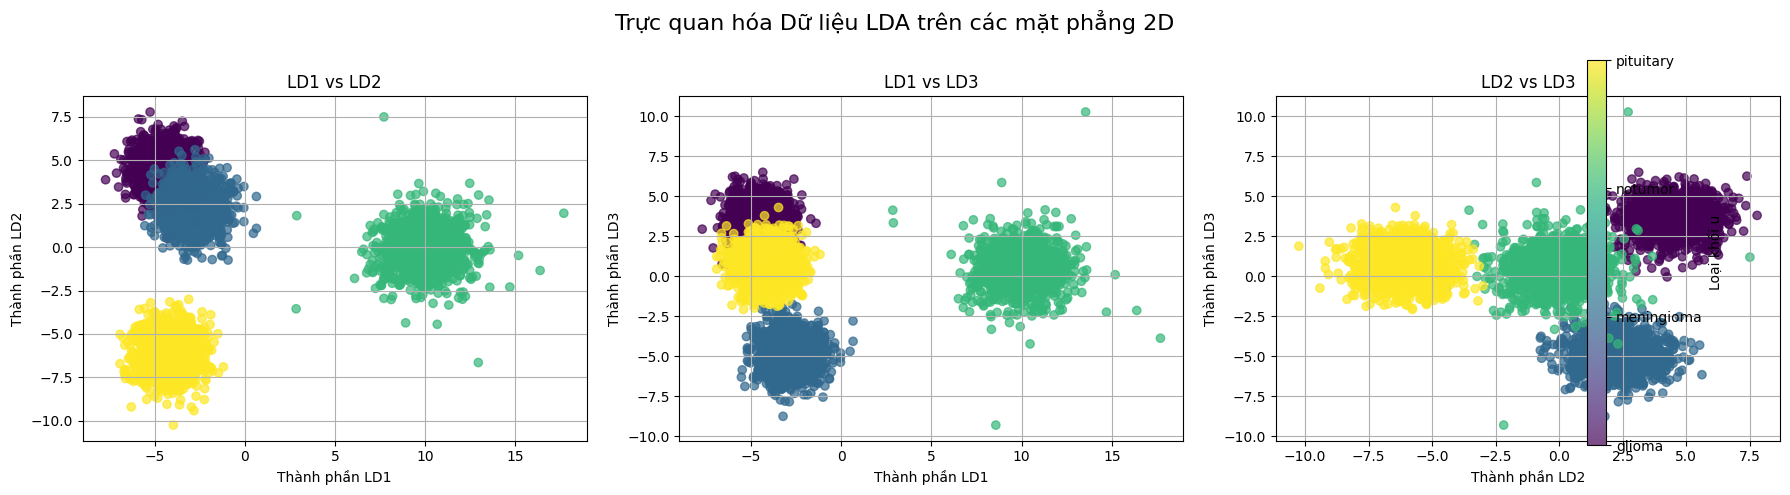


Đang vẽ biểu đồ 3D tương tác...


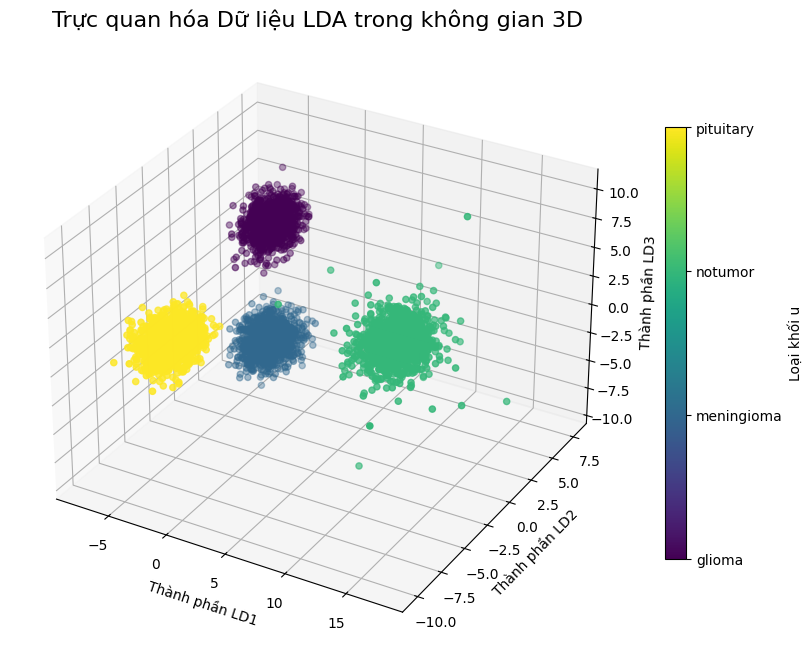

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import itertools

# --- 1. Trực quan hóa trên các mặt phẳng 2D ---
print("Đang vẽ các biểu đồ 2D để xem sự phân tách lớp...")

# Lấy các cặp kết hợp của 3 chiều (0, 1), (0, 2), (1, 2)
pairs_lda = list(itertools.combinations(range(X_train_lda.shape[1]), 2))
class_names = label_encoder.classes_

plt.figure(figsize=(18, 5))
plt.suptitle("Trực quan hóa Dữ liệu LDA trên các mặt phẳng 2D", fontsize=16)

for i, (x_idx, y_idx) in enumerate(pairs_lda):
    plt.subplot(1, 3, i + 1)
    # Vẽ các điểm dữ liệu, tô màu theo nhãn thật (y_train_encoded)
    scatter = plt.scatter(
        X_train_lda[:, x_idx],
        X_train_lda[:, y_idx],
        c=y_train_encoded,
        cmap='viridis',
        alpha=0.7
    )
    plt.xlabel(f"Thành phần LD{x_idx + 1}")
    plt.ylabel(f"Thành phần LD{y_idx + 1}")
    plt.title(f"LD{x_idx + 1} vs LD{y_idx + 1}")
    plt.grid(True)

# Thêm một thanh màu (colorbar) chung để làm chú giải cho các lớp
cbar = plt.colorbar(scatter, ax=plt.gcf().get_axes(), orientation='vertical', fraction=.02, pad=0.04)
cbar.set_ticks(range(len(class_names)))
cbar.set_ticklabels(class_names)
cbar.set_label('Loại khối u')

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Chỉnh layout để không bị che mất suptitle
plt.show()


# --- 2. Trực quan hóa trong không gian 3D ---
# (Trong một số môi trường như Jupyter Lab, bạn có thể cần chạy: %matplotlib widget)
print("\nĐang vẽ biểu đồ 3D tương tác...")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Vẽ các điểm dữ liệu trong không gian 3D
scatter_3d = ax.scatter(
    X_train_lda[:, 0],  # Trục x là LD1
    X_train_lda[:, 1],  # Trục y là LD2
    X_train_lda[:, 2],  # Trục z là LD3
    c=y_train_encoded,
    cmap='viridis',
    s=20 # Kích thước điểm
)

ax.set_title("Trực quan hóa Dữ liệu LDA trong không gian 3D", fontsize=16)
ax.set_xlabel("Thành phần LD1")
ax.set_ylabel("Thành phần LD2")
ax.set_zlabel("Thành phần LD3")

# Thêm chú giải bằng colorbar
cbar_3d = fig.colorbar(scatter_3d, shrink=0.7)
cbar_3d.set_ticks(range(len(class_names)))
cbar_3d.set_ticklabels(class_names)
cbar_3d.set_label('Loại khối u')

plt.show()